# Reducing data-cubes over geometries

In [1]:
from earthkit import data as ekd
from earthkit import geo as ekg
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.transforms._tools import earthkit_remote_test_data_file

## Load some test data

In this example we will use hourly ERA5 2m temperature data on a 0.5x0.5 spatial grid for the year 2015 as
our physical data; and we will use the NUTS regions geometries which are available in `earthkit.geo`.

In [2]:
# NUTS regions
nuts_data = ekg.gisco.nuts_regions(level=0).to_geopandas()
nuts_data.head()

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,BA,0,BA,Bosna I Hercegovina,Bosna I Hercegovina,0.0,NaN,NaN,Bosnia and Herzegovina,Bosnie-et-Herzégovine,BIH,UN Member State,Sarajevo,F,F,T,Bosnien und Herzegowina,"MULTIPOLYGON (((16.92382 45.26542, 17.14119 45..."
1,BE,0,BE,Belgique/België,Belgique/België,NaN,NaN,NaN,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"POLYGON ((4.82637 51.48207, 4.84186 51.42493, ..."
2,BG,0,BG,Bulgaria,България,NaN,NaN,NaN,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"POLYGON ((22.88233 43.83546, 22.99717 43.80787..."
3,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,NaN,NaN,NaN,Switzerland,Suisse,CHE,UN Member State,Bern,F,T,F,Schweiz,"POLYGON ((8.70462 47.75557, 8.72798 47.69268, ..."
4,CY,0,CY,Kýpros,Κύπρος,NaN,NaN,NaN,Cyprus,Chypre,CYP,UN Member State,Nicosia,T,F,F,Zypern,"POLYGON ((32.25443 35.06555, 32.42709 35.08197..."


In [3]:
remote_era5_file = earthkit_remote_test_data_file("era5_temperature_europe_20150101.grib")
era5_data = ekd.from_source("url", remote_era5_file)
# Convert to xarray and select the first time step for plotting
era5_xr = era5_data.to_xarray(time_dims=["valid_time"]).rename({"2t": "t2m"}).isel(valid_time=0)
era5_xr

<xarray.Dataset> Size: 456kB
Dimensions:     (latitude: 201, longitude: 281)
Coordinates:
  * latitude    (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 2kB -10.0 -9.75 -9.5 ... 59.5 59.75 60.0
    valid_time  datetime64[ns] 8B 2015-01-01
Data variables:
    t2m         (latitude, longitude) float64 452kB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Reduce data

In [4]:
reduced_data = ekt.spatial.reduce(
    era5_xr,
    nuts_data,
    mask_dim="NAME_ENGL",
    how="mean",  # Default value
)
reduced_data

<xarray.Dataset> Size: 632B
Dimensions:     (NAME_ENGL: 39)
Coordinates:
  * NAME_ENGL   (NAME_ENGL) object 312B 'Bosnia and Herzegovina' ... 'Kosovo'
    valid_time  datetime64[ns] 8B 2015-01-01
Data variables:
    t2m         (NAME_ENGL) float64 312B 259.4 273.0 261.6 ... 275.8 261.6 262.5
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Now we add the temperature data to the geopandas for easier plotting.

In [5]:
nuts_data = nuts_data.assign(t2m=reduced_data.t2m)
nuts_data.head()

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry,t2m
0,BA,0,BA,Bosna I Hercegovina,Bosna I Hercegovina,0.0,NaN,NaN,Bosnia and Herzegovina,Bosnie-et-Herzégovine,BIH,UN Member State,Sarajevo,F,F,T,Bosnien und Herzegowina,"MULTIPOLYGON (((16.92382 45.26542, 17.14119 45...",259.419122
1,BE,0,BE,Belgique/België,Belgique/België,NaN,NaN,NaN,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"POLYGON ((4.82637 51.48207, 4.84186 51.42493, ...",273.033030
2,BG,0,BG,Bulgaria,България,NaN,NaN,NaN,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"POLYGON ((22.88233 43.83546, 22.99717 43.80787...",261.594039
3,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,NaN,NaN,NaN,Switzerland,Suisse,CHE,UN Member State,Bern,F,T,F,Schweiz,"POLYGON ((8.70462 47.75557, 8.72798 47.69268, ...",264.903833
4,CY,0,CY,Kýpros,Κύπρος,NaN,NaN,NaN,Cyprus,Chypre,CYP,UN Member State,Nicosia,T,F,F,Zypern,"POLYGON ((32.25443 35.06555, 32.42709 35.08197...",285.788853


Below we plot the geopandas dataframe using the `geo.choropleth` method in `earthkit.plots`.

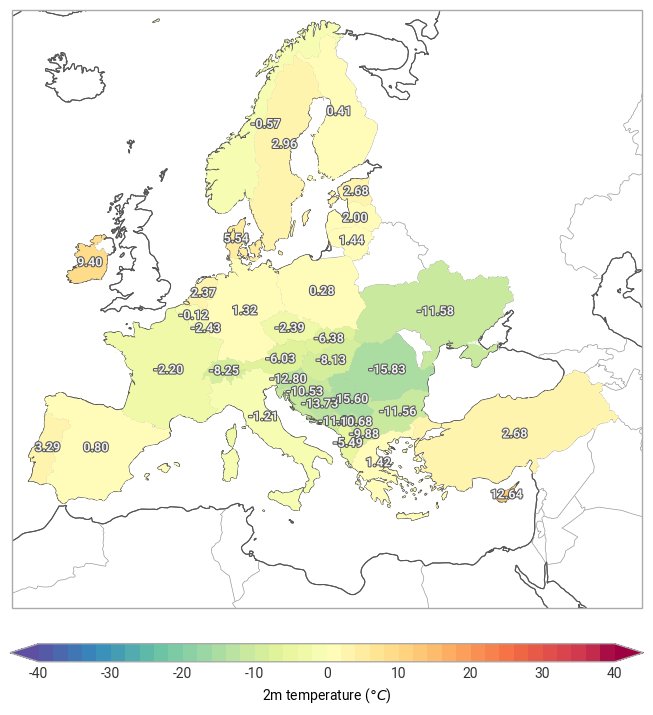

In [6]:
fig = ekp.geo.choropleth(
    nuts_data,
    z="t2m",
    domain="Europe",
    metadata={"units": "K", "long_name": "2m temperature"},
    units="celsius",
    labels="{t2m:0.2f}",
)
fig.coastlines()
fig.borders()
fig.show()